In [1]:
# Setup — run this cell first
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir('../..')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

ADP_PATH  = 'data/04_results/lacity_apd_building_features.gpkg'
UDU_PATH  = 'data/01_raw/UDU Report 02_10_2026.csv'
NO_UDU_AINS_PATH = 'data/04_results/no_udu_clean_ains.csv'
UDU_AINS_PATH    = 'data/04_results/udu_ains.csv'

print("Ready.")


Ready.


# Identifying Unpermitted Dwelling Units in Los Angeles
## Methodology Report — Building a Clean Control Sample

This report documents the process of constructing two comparable samples of LA City residential parcels:

- **Known UDU**: parcels with a confirmed unpermitted dwelling unit filing (LA City UDU amnesty program, 2017–2025)
- **Clean control (no-UDU)**: parcels where available evidence gives high confidence that no unpermitted dwelling unit was present during the study window (2014–2017)

The goal is to characterise what distinguishes UDU parcels from ordinary residential parcels, and to validate the control sample against the known UDU characteristics.

---

### Data Sources

| Dataset | Description | Vintage | Records |
|---|---|---|---|
| LARIAC building footprints | LiDAR-derived building polygon geometries for LA County | 2014, 2017, 2020 | ~8M footprints |
| LA County Assessor rolls | Recorded building attributes (sqft, use type, year built, value) | 2006–2024 | ~1.4M parcels/year |
| Symdiff (building change) | Parcel-level summary of footprint changes between LARIAC epochs | 2014→2017, 2017→2020 | ~625k parcels |
| `assessor_lariac.gpkg` | Pre-joined parcel × LARIAC metrics (floor area, lot area, building count) | 2014, 2017, 2020 | ~1.4M parcels |
| UDU amnesty filings | LA City Planning Department records of UDU disclosure filings | 2017–2025 | 448 cases |

---
## Part 1 — Building the Clean Control Sample

Seven successive filters reduce the 625k-parcel symdiff universe to a high-confidence no-UDU sample. Each filter is grounded in a specific rationale.

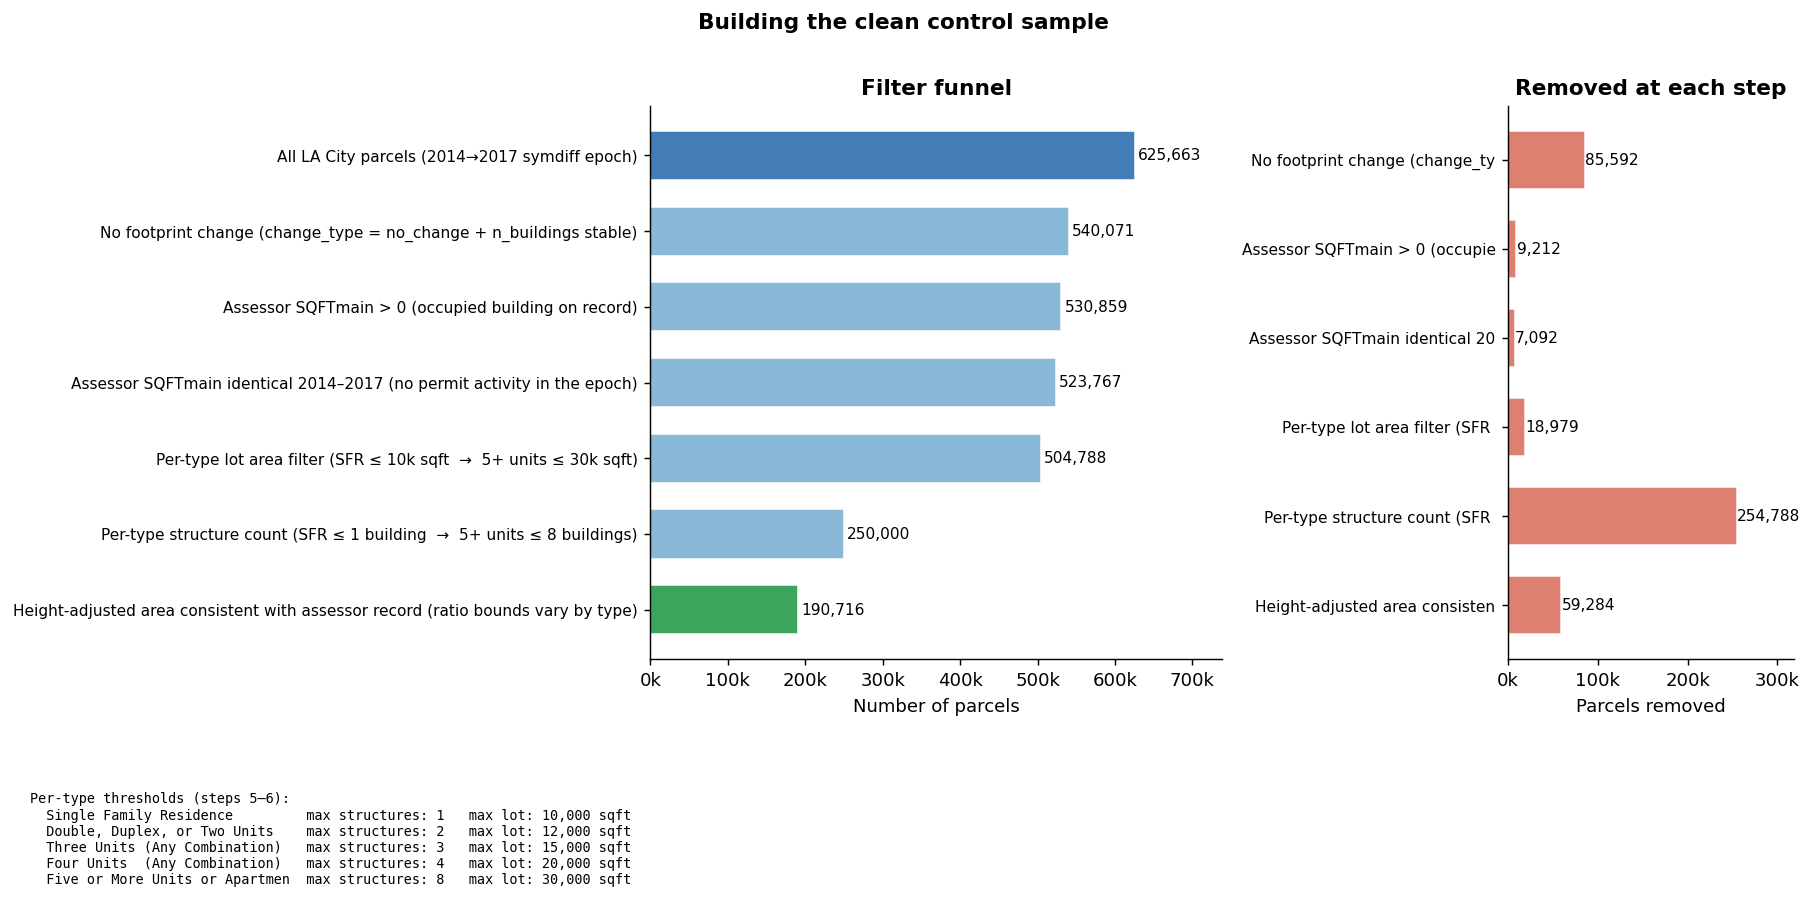


Final clean control sample: 190,716 parcels  (30.5% of starting universe)


In [2]:
import os

# Load actual final no-UDU count from nb_09 checkpoint if available
_ains_path = 'data/04_results/no_udu_clean_ains.csv'
_final_n   = len(pd.read_csv(_ains_path)) if os.path.exists(_ains_path) else 169_882

# Per-type thresholds applied at steps 5 & 6
TYPE_THRESHOLDS = {
    'Single Family Residence':                            {'max_n': 1,  'max_lot': 10_000},
    'Double, Duplex, or Two Units':                       {'max_n': 2,  'max_lot': 12_000},
    'Three Units (Any Combination)':                      {'max_n': 3,  'max_lot': 15_000},
    'Four Units  (Any Combination)':                      {'max_n': 4,  'max_lot': 20_000},
    'Five or More Units or Apartments (Any Combination)': {'max_n': 8,  'max_lot': 30_000},
}

FUNNEL = [
    ("All LA City parcels (2014→2017 symdiff epoch)",       625_663),
    ("No footprint change (change_type = no_change + n_buildings stable)", 540_071),
    ("Assessor SQFTmain > 0 (occupied building on record)", 530_859),
    ("Assessor SQFTmain identical 2014–2017 (no permit activity in the epoch)", 523_767),
    ("Per-type lot area filter (SFR ≤ 10k sqft  →  5+ units ≤ 30k sqft)", 504_788),
    ("Per-type structure count (SFR ≤ 1 building  →  5+ units ≤ 8 buildings)", 250_000),
    ("Height-adjusted area consistent with assessor record (ratio bounds vary by type)", _final_n),
]

labels  = [f[0] for f in FUNNEL]
counts  = [f[1] for f in FUNNEL]
removed = [counts[i-1] - counts[i] for i in range(1, len(counts))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
colors = ['#2166ac'] + ['#74add1'] * (len(FUNNEL) - 2) + ['#1a9641']
bars = ax.barh(range(len(FUNNEL)), counts, color=colors, alpha=0.85,
               edgecolor='white', height=0.65)
ax.set_yticks(range(len(FUNNEL)))
ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel('Number of parcels')
ax.set_title('Filter funnel', fontweight='bold')
for bar, v in zip(bars, counts):
    ax.text(bar.get_width() + 4000, bar.get_y() + bar.get_height() / 2,
            f'{v:,}', va='center', fontsize=8.5)
ax.set_xlim(0, max(counts) * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

ax2 = axes[1]
step_labels = [labels[i+1].split('\n')[0][:30] for i in range(len(removed))]
ax2.barh(range(len(removed)), removed, color='#d6604d', alpha=0.8,
         edgecolor='white', height=0.65)
ax2.set_yticks(range(len(removed)))
ax2.set_yticklabels(step_labels, fontsize=8.5)
ax2.invert_yaxis()
ax2.set_xlabel('Parcels removed')
ax2.set_title('Removed at each step', fontweight='bold')
for i, v in enumerate(removed):
    ax2.text(v + 500, i, f'{v:,}', va='center', fontsize=8.5)
ax2.set_xlim(0, max(removed) * 1.25)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Per-type threshold legend
legend_text = '\n'.join(
    f'  {k[:30]:<30}  max structures: {v["max_n"]}   max lot: {v["max_lot"]:,} sqft'
    for k, v in TYPE_THRESHOLDS.items()
)
fig.text(0.02, -0.08, f'Per-type thresholds (steps 5–6):\n{legend_text}',
         fontsize=7.5, family='monospace', va='top')

plt.suptitle('Building the clean control sample', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"\nFinal clean control sample: {_final_n:,} parcels  "
      f"({_final_n/counts[0]*100:.1f}% of starting universe)")


---
## Part 2 — Sample Comparison: Known UDU vs Clean Control

The following charts and table compare the two samples across structural, demographic, and spatial features.

In [3]:
ADP_COLS = [
    'AIN', 'RollYear',
    'YearBuilt', 'EffectiveYearBuilt',
    'SQFTmain', 'Bedrooms', 'Bathrooms', 'Units',
    'totBuildingDataLines', 'ImprovementValue', 'LandValue', 'TotalValue',
    'SpecificUseType', 'GeneralUseType',
    'parcels.far', 'sp.bar', 'sp.far',
    'sp.ratio.floorarea', 'sp.resid.floorarea',
    'shape.area.sum', 'shape.area.max', 'shape.floorarea.sum', 'shape.n_buildings',
    'LotArea', 'Neighborhood', 'CENTER_LAT', 'CENTER_LON',
]
# ADP is a 3-epoch panel — filter to 2017
adp = (
    gpd.read_file(ADP_PATH, layer='lacity_apd_building_features', columns=ADP_COLS)
    .drop(columns='geometry')
    .dropna(subset=['AIN'])
    .assign(AIN=lambda x: x['AIN'].astype(int).astype(str))
    .query('RollYear == 2017')
    .drop_duplicates('AIN')
)
print(f'ADP 2017 rows: {len(adp):,}')

no_udu_ains = pd.read_csv(NO_UDU_AINS_PATH, dtype={'AIN': str}).drop_duplicates()
udu_ains    = pd.read_csv(UDU_AINS_PATH,    dtype={'AIN': str}).drop_duplicates()

udu_report = pd.read_csv(UDU_PATH, parse_dates=['filing_date'])
udu_report['AIN'] = udu_report['assessor_parcel_number'].astype(str)

no_udu = adp[adp.AIN.isin(no_udu_ains.AIN)].copy().assign(label='No-UDU (control)')
udu    = (
    adp[adp.AIN.isin(udu_ains.AIN)]
    .merge(udu_report[['AIN','filing_date','Approved Units']].drop_duplicates('AIN'), on='AIN', how='left')
    .assign(label='Known UDU')
)
for df in (no_udu, udu):
    df['age_2017'] = 2017 - df['YearBuilt']

print(f'No-UDU (control): {len(no_udu):,} parcels')
print(f'Known UDU:        {len(udu):,} parcels')


ADP 2017 rows: 581,764
No-UDU (control): 176,221 parcels
Known UDU:        393 parcels


In [4]:
# ── Derived features ─────────────────────────────────────────────────────────
TRACT_PATH = 'data/03_processed/assessor_udu_tracts.gpkg'
tract_data = (
    gpd.read_file(TRACT_PATH, layer='parcels', columns=['AIN','GEOID_TRACT','n_udu'])
    .drop(columns='geometry')
    .assign(AIN=lambda x: x['AIN'].astype(str))
    .drop_duplicates('AIN')
    .rename(columns={'n_udu': 'n_udu_tract'})
)

# Symdiff-based area features saved by nb_09
NO_UDU_SYM = 'data/04_results/no_udu_symdiff_feats.csv'
UDU_SYM    = 'data/04_results/udu_symdiff_feats.csv'
symdiff_no_udu = pd.read_csv(NO_UDU_SYM, dtype={'AIN': str}) if os.path.exists(NO_UDU_SYM) else pd.DataFrame(columns=['AIN'])
symdiff_udu    = pd.read_csv(UDU_SYM,    dtype={'AIN': str}) if os.path.exists(UDU_SYM)    else pd.DataFrame(columns=['AIN'])

def add_features(df, symdiff_df):
    df = df.copy()
    # Derived from ADP
    df['renov_gap']       = (df['EffectiveYearBuilt'] - df['YearBuilt']).clip(lower=0)
    df['bath_per_unit']   = df['Bathrooms']        / df['Units'].replace(0, np.nan)
    df['bdrm_per_sqft']   = df['Bedrooms']         / df['SQFTmain'].replace(0, np.nan) * 100
    df['imp_per_sqft']    = df['ImprovementValue']  / df['SQFTmain'].replace(0, np.nan)
    df['struct_unit_gap'] = df['shape.n_buildings'] - df['Units']
    df['multi_bldg_flag'] = (df['totBuildingDataLines'] > 1).astype(float)
    df['resid_floor_gap'] = df['sp.resid.floorarea'] - df['SQFTmain']
    df['dominance_ratio'] = df['shape.area.max'] / df['shape.area.sum'].replace(0, np.nan)
    df['land_value_share']= df['LandValue'] / df['TotalValue'].replace(0, np.nan)
    # Tract UDU intensity
    df = df.merge(tract_data[['AIN','GEOID_TRACT','n_udu_tract']], on='AIN', how='left')
    # Symdiff geometry-based floor area
    if not symdiff_df.empty:
        df = df.merge(symdiff_df, on='AIN', how='left')
    return df

no_udu = add_features(no_udu, symdiff_no_udu)
udu    = add_features(udu,    symdiff_udu)
print('Derived features added.')
print(f"gross_sqft_geom available: {'gross_sqft_geom' in no_udu.columns}")


Derived features added.
gross_sqft_geom available: True


In [5]:
# ── TCAC/HCD 2021 Opportunity Map — spatial join via lat/lon ─────────────────
import requests, os

TCAC_GPKG  = 'data/04_results/tcac_opportunity_la.gpkg'
TCAC_URL   = (
    'https://services5.arcgis.com/wXYNaciObHUosEnt/arcgis/rest/services/'
    '2021_TCAC_HCD_High_Opportunity_Map_WFL1/FeatureServer/0/query'
)
OPPCAT_ORDER = [
    'Highest Segregation & Poverty', 'High Segregation & Poverty',
    'Low Resource', 'Moderate Resource', 'High Resource', 'Highest Resource',
]

# Load or fetch TCAC polygon layer
if os.path.exists(TCAC_GPKG):
    tcac_gdf = gpd.read_file(TCAC_GPKG)
    print(f'Loaded from cache: {len(tcac_gdf):,} LA tracts')
else:
    import json as _json
    features, offset = [], 0
    while True:
        r = requests.get(TCAC_URL, params={
            'where': "cnty_nm='Los Angeles'",
            'outFields': 'fips,oppcat,ecn_dmn,env_hl_,ed_domn,index_',
            'returnGeometry': 'true', 'outSR': '4326',
            'resultOffset': offset, 'resultRecordCount': 1000, 'f': 'geojson',
        }, timeout=30)
        data = r.json()
        feats = data.get('features', [])
        if not feats: break
        features.extend(feats)
        if not data.get('exceededTransferLimit', False): break
        offset += 1000
    tcac_gdf = (
        gpd.read_file(_json.dumps({'type': 'FeatureCollection', 'features': features}))
        .rename(columns={'fips': 'GEOID_TRACT', 'index_': 'opp_index',
                         'ecn_dmn': 'opp_econ', 'env_hl_': 'opp_env',
                         'ed_domn': 'opp_educ', 'oppcat': 'opp_cat'})
    )
    tcac_gdf['opp_cat_rank'] = pd.Categorical(
        tcac_gdf['opp_cat'], categories=OPPCAT_ORDER, ordered=True).codes
    tcac_gdf.to_file(TCAC_GPKG, driver='GPKG')
    print(f'Fetched and cached: {len(tcac_gdf):,} LA tracts')

# Spatial join: parcel lat/lon → TCAC polygon → opp_cat
TCAC_COLS = ['opp_cat', 'opp_cat_rank', 'opp_index', 'opp_econ', 'opp_env', 'opp_educ']

def assign_tcac(df):
    df = df.drop(columns=[c for c in TCAC_COLS if c in df.columns], errors='ignore')
    valid = df['CENTER_LAT'].notna() & df['CENTER_LON'].notna()
    if not valid.any():
        return df
    pts = gpd.GeoDataFrame(
        df.loc[valid, ['AIN']].copy(),
        geometry=gpd.points_from_xy(df.loc[valid, 'CENTER_LON'],
                                     df.loc[valid, 'CENTER_LAT']), crs=4326
    )
    joined = (
        gpd.sjoin(pts, tcac_gdf[TCAC_COLS + ['geometry']].to_crs(4326),
                  how='left', predicate='within')
        .drop(columns=['index_right'], errors='ignore')
        .drop_duplicates(subset=['AIN'], keep='first')
        .set_index('AIN')[TCAC_COLS]
    )
    for col in TCAC_COLS:
        df[col] = df['AIN'].map(joined[col])
    print(f"  TCAC assigned: {df['opp_cat'].notna().sum():,} / {len(df):,} parcels")
    return df

no_udu = assign_tcac(no_udu)
udu    = assign_tcac(udu)
adp    = assign_tcac(adp)
combined = pd.concat([no_udu, udu], ignore_index=True)

print('\nUDU opp_cat:')
print(udu['opp_cat'].value_counts().reindex(OPPCAT_ORDER).dropna().to_string())


Loaded from cache: 1,000 LA tracts
  TCAC assigned: 173,565 / 176,221 parcels
  TCAC assigned: 392 / 393 parcels
  TCAC assigned: 573,560 / 581,764 parcels

UDU opp_cat:
opp_cat
High Segregation & Poverty     82.0
Low Resource                  116.0
Moderate Resource              56.0
High Resource                  55.0
Highest Resource               70.0


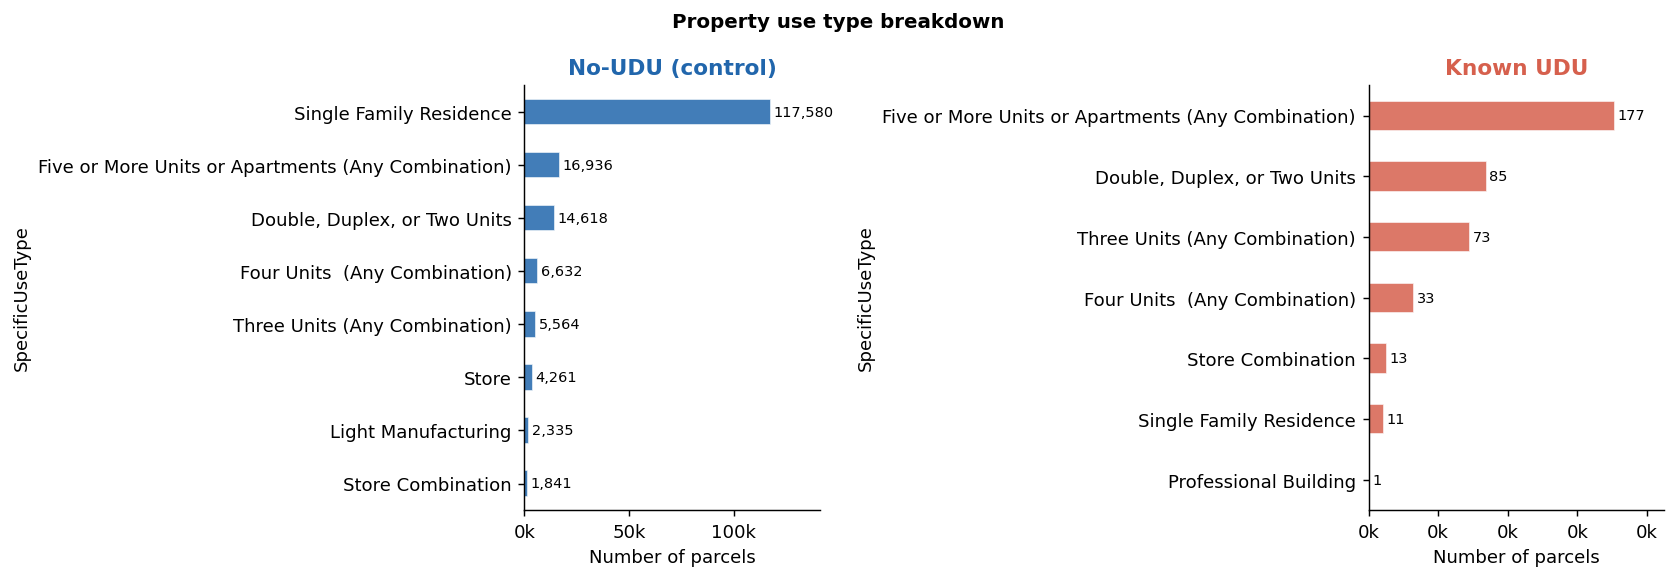

In [6]:
PALETTE = {'No-UDU (control)': '#2166ac', 'Known UDU': '#d6604d'}

# ── Use type breakdown ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, df) in zip(axes, [('No-UDU (control)', no_udu), ('Known UDU', udu)]):
    top = df['SpecificUseType'].value_counts().head(8)
    top.plot.barh(ax=ax, color=PALETTE[label], alpha=0.85, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Number of parcels')
    ax.set_title(label, fontweight='bold', color=PALETTE[label])
    for i, v in enumerate(top):
        ax.text(v + top.max() * 0.01, i, f'{v:,}', va='center', fontsize=8)
    ax.set_xlim(0, top.max() * 1.2)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.suptitle('Property use type breakdown', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


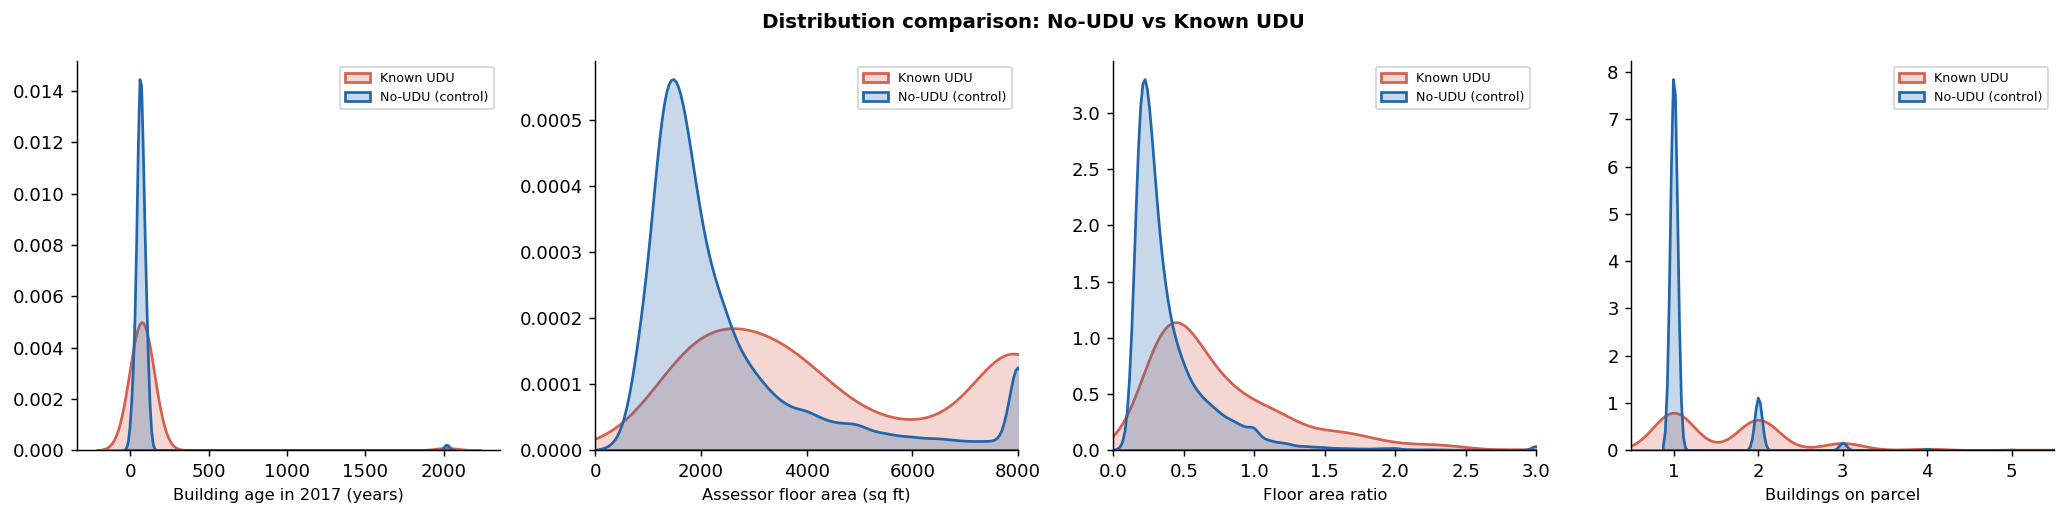

In [7]:
# ── Key distributions: age, building size, FAR ───────────────────────────────
FEATURES = [
    ('age_2017',    'Building age in 2017 (years)',    None),
    ('SQFTmain',    'Assessor floor area (sq ft)',      (0, 8000)),
    ('parcels.far', 'Floor area ratio',                 (0, 3)),
    ('shape.n_buildings', 'Buildings on parcel',        (0.5, 5.5)),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (feat, xlabel, xlim) in zip(axes, FEATURES):
    for label, grp in combined.groupby('label'):
        d = grp[feat].dropna()
        if xlim:
            d = d.clip(*xlim)
        sns.kdeplot(d, ax=ax, label=label, color=PALETTE[label],
                    fill=True, alpha=0.25, linewidth=1.5)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('')
    if xlim:
        ax.set_xlim(*xlim)
    ax.legend(fontsize=7)

plt.suptitle('Distribution comparison: No-UDU vs Known UDU', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ── Summary statistics table ──────────────────────────────────────────────────
STAT_FEATURES = {
    'age_2017':           'Building age (years)',
    'SQFTmain':           'Assessor floor area (sq ft)',
    'LotArea':            'Lot area (sq ft)',
    'parcels.far':        'Floor area ratio',
    'sp.bar':             'Building coverage ratio',
    'shape.n_buildings':  'Structures on parcel',
    'Units':              'Recorded unit count',
    'renov_gap':          'Renovation gap (EffYr − YrBuilt)',
    'bath_per_unit':      'Bathrooms per unit',
    'imp_per_sqft':       'Improvement value per sqft',
    'struct_unit_gap':    'LARIAC structures − assessed units',
    'n_udu_tract':        'UDU filings in census tract',
    'opp_cat_rank':       'Opportunity category (0=lowest)',
}

rows = []
for col, display in STAT_FEATURES.items():
    for label, grp in combined.groupby('label'):
        d = grp[col].dropna()
        rows.append({
            'Feature': display,
            'Sample': label,
            'Median': d.median(),
            'Mean': d.mean(),
            'Std': d.std(),
            'n': len(d),
        })

stats_table = (
    pd.DataFrame(rows)
    .pivot_table(index='Feature', columns='Sample',
                 values=['Median', 'Mean'], aggfunc='first')
    .round(1)
)
# Flatten column names
stats_table.columns = [f'{stat} — {label}' for stat, label in stats_table.columns]
stats_table


,Mean — Known UDU,Mean — No-UDU (control),Median — Known UDU,Median — No-UDU (control)
Feature,,,,
Assessor floor area (sq ft),8098.9,2965.2,3700.0,1845.0
Bathrooms per unit,1.2,1.9,1.0,2.0
Building age (years),102.8,82.7,79.0,64.0
Building coverage ratio,0.4,0.4,0.4,0.4
Floor area ratio,0.8,0.4,0.6,0.3
Improvement value per sqft,68.8,81.0,63.6,74.9
LARIAC structures − assessed units,-7.7,-1.2,-2.0,0.0
Lot area (sq ft),9089.8,6745.8,6675.4,6563.6
Opportunity category (0=lowest),2.7,3.1,2.0,3.0


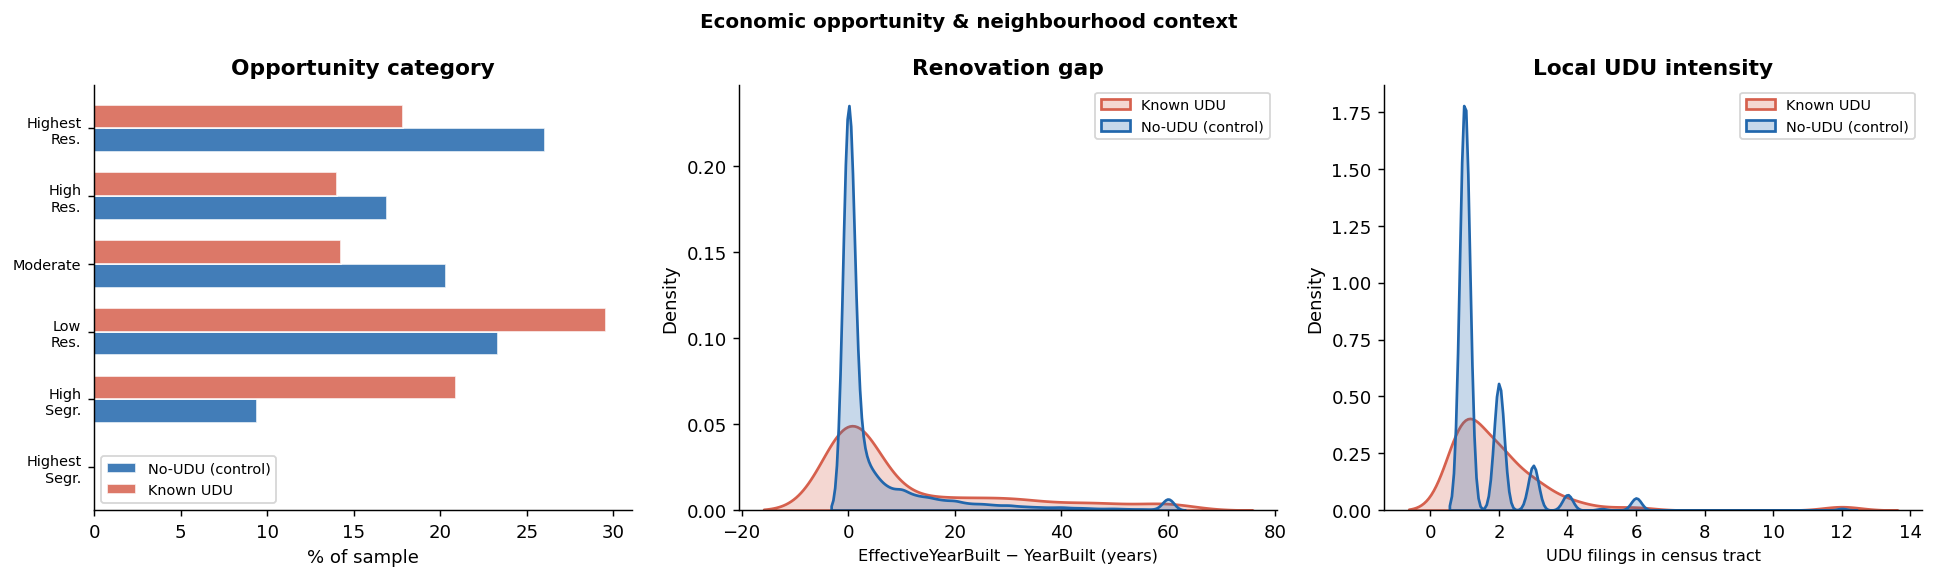

In [9]:
# ── Opportunity category + new feature distributions ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: opportunity category grouped bar
ax = axes[0]
x = np.arange(len(OPPCAT_ORDER))
w = 0.35
for j, (label, color) in enumerate(PALETTE.items()):
    sub = combined[combined.label == label].dropna(subset=['opp_cat'])
    counts = sub['opp_cat'].value_counts()
    vals = [counts.get(c, 0) / len(sub) * 100 for c in OPPCAT_ORDER]
    ax.barh(x + j*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
short = ['Highest\nSegr.','High\nSegr.','Low\nRes.','Moderate','High\nRes.','Highest\nRes.']
ax.set_yticks(x + w/2); ax.set_yticklabels(short, fontsize=8)
ax.set_xlabel('% of sample'); ax.set_title('Opportunity category', fontweight='bold')
ax.legend(fontsize=8)

# Panel 2: renovation gap KDE
ax2 = axes[1]
for label, grp in combined.groupby('label'):
    d = grp['renov_gap'].clip(0, 60).dropna()
    sns.kdeplot(d, ax=ax2, label=label, color=PALETTE[label], fill=True, alpha=0.25, linewidth=1.5)
ax2.set_xlabel('EffectiveYearBuilt − YearBuilt (years)', fontsize=9)
ax2.set_title('Renovation gap', fontweight='bold'); ax2.legend(fontsize=8)

# Panel 3: local UDU tract intensity
ax3 = axes[2]
for label, grp in combined.groupby('label'):
    d = grp['n_udu_tract'].clip(0, 20).dropna()
    sns.kdeplot(d, ax=ax3, label=label, color=PALETTE[label], fill=True, alpha=0.25, linewidth=1.5)
ax3.set_xlabel('UDU filings in census tract', fontsize=9)
ax3.set_title('Local UDU intensity', fontweight='bold'); ax3.legend(fontsize=8)

plt.suptitle('Economic opportunity & neighbourhood context', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


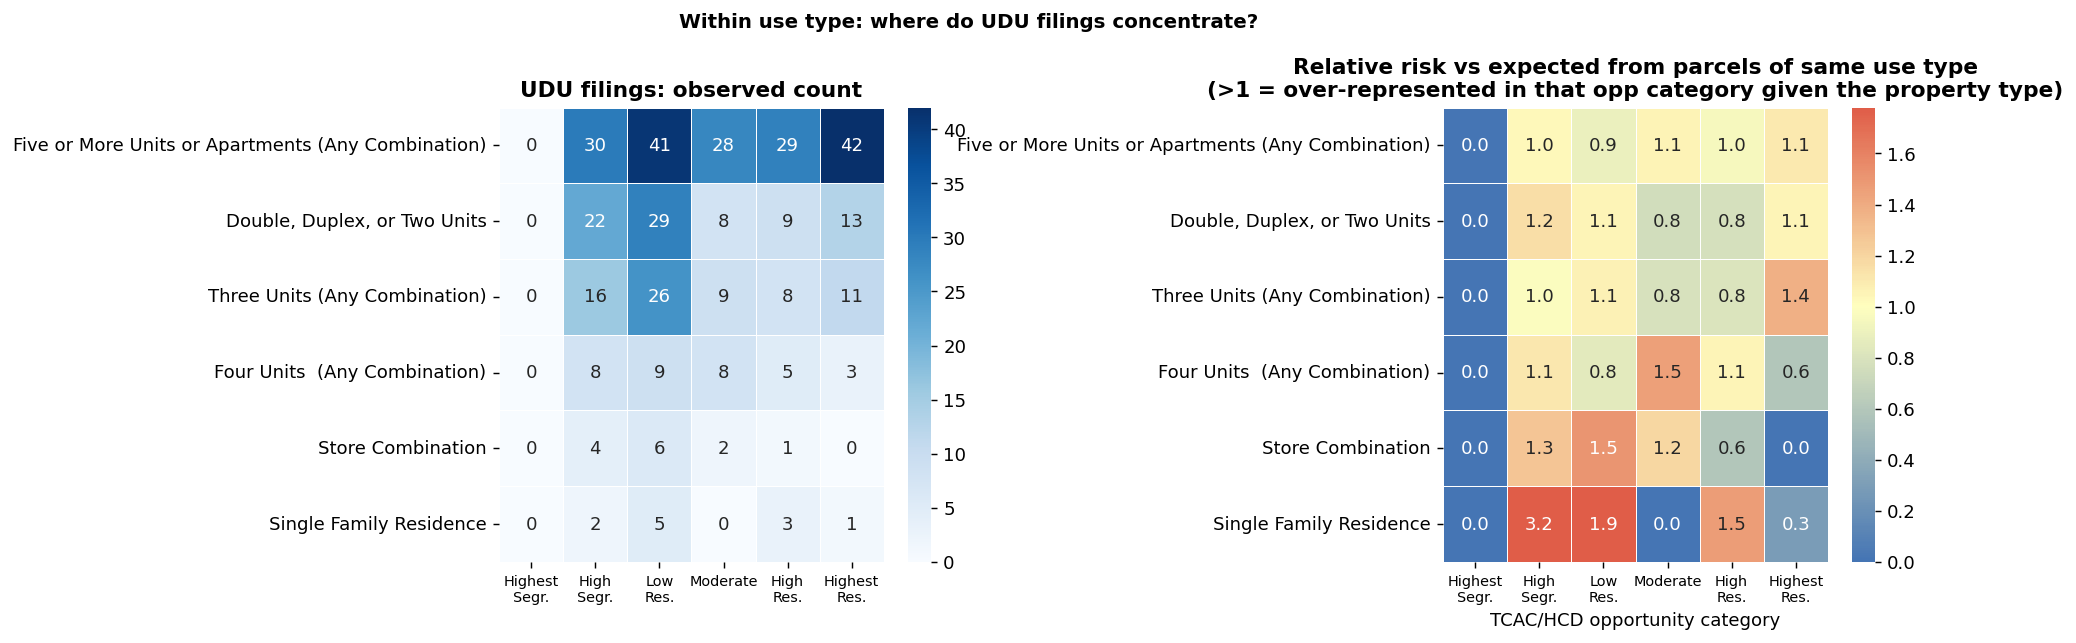

,SpecificUseType,opp_cat,n_udu,expected,rr
32,Single Family Residence,Low Resource,5,2.60,1.92
26,Store Combination,Low Resource,6,3.97,1.51
21,Four Units (Any Combination),Moderate Resource,8,5.49,1.46
17,Three Units (Any Combination),Highest Resource,11,8.02,1.37
7,"Double, Duplex, or Two Units",High Segregation & Poverty,22,18.95,1.16
19,Four Units (Any Combination),High Segregation & Poverty,8,7.16,1.12
5,Five or More Units or Apartments (Any Combinat...,Highest Resource,42,38.06,1.10
14,Three Units (Any Combination),Low Resource,26,24.31,1.07
3,Five or More Units or Apartments (Any Combinat...,Moderate Resource,28,26.45,1.06
8,"Double, Duplex, or Two Units",Low Resource,29,27.44,1.06


In [10]:
# ── Relative risk: within use type, across opportunity categories ─────────────
# For each use type, how does the opp_cat distribution of UDU filings compare
# to the opp_cat distribution of ALL parcels of that same use type?
# RR > 1 → UDU filings are concentrated in that opp category more than expected
# given where parcels of that type actually sit.
import matplotlib.colors as mcolors

TOP_TYPES  = udu['SpecificUseType'].value_counts().head(6).index.tolist()
SHORT_COLS = ['Highest\nSegr.','High\nSegr.','Low\nRes.','Moderate','High\nRes.','Highest\nRes.']

def make_ct(df, types):
    return (
        df[df.SpecificUseType.isin(types)]
        .groupby(['SpecificUseType','opp_cat']).size()
        .unstack('opp_cat', fill_value=0)
        .reindex(index=types, columns=OPPCAT_ORDER, fill_value=0)
    )

udu_ct = make_ct(udu, TOP_TYPES)
adp_ct = make_ct(adp.dropna(subset=['SpecificUseType','opp_cat']), TOP_TYPES)

# Within-use-type expected: row share of adp × row total of udu
# = "if UDU were proportional to where parcels of this type sit"
adp_row_share = adp_ct.div(adp_ct.sum(axis=1).replace(0, np.nan), axis=0)
expected = adp_row_share.mul(udu_ct.sum(axis=1), axis=0)
rr = (udu_ct / expected.replace(0, np.nan)).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: observed count
sns.heatmap(udu_ct, ax=axes[0], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, xticklabels=SHORT_COLS, linecolor='white')
axes[0].set_title('UDU filings: observed count', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=8)

# Right: within-use-type relative risk across opp_cat
cmap_rr = mcolors.LinearSegmentedColormap.from_list('rr', ['#4575b4','#ffffbf','#d73027'])
vmax = min(8, float(np.nanpercentile(rr.replace(0, np.nan).values.flatten(), 95)))
sns.heatmap(rr, ax=axes[1], cmap=cmap_rr, center=1.0, vmin=0, vmax=vmax,
            annot=True, fmt='.1f', linewidths=0.5, xticklabels=SHORT_COLS, linecolor='white')
axes[1].set_title(
    'Relative risk vs expected from parcels of same use type\n'
    '(>1 = over-represented in that opp category given the property type)',
    fontweight='bold')
axes[1].set_xlabel('TCAC/HCD opportunity category'); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('Within use type: where do UDU filings concentrate?',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Top 10 cells by relative risk (min 5 observed)
rr_flat = (
    rr.stack().rename('rr').to_frame()
    .join(udu_ct.stack().rename('n_udu'))
    .join(expected.stack().rename('expected'))
    .reset_index()
    .query('n_udu >= 5')
    .sort_values('rr', ascending=False)
    .head(10)
)
rr_flat.columns.name = None
rr_flat[['SpecificUseType','opp_cat','n_udu','expected','rr']].round(2)


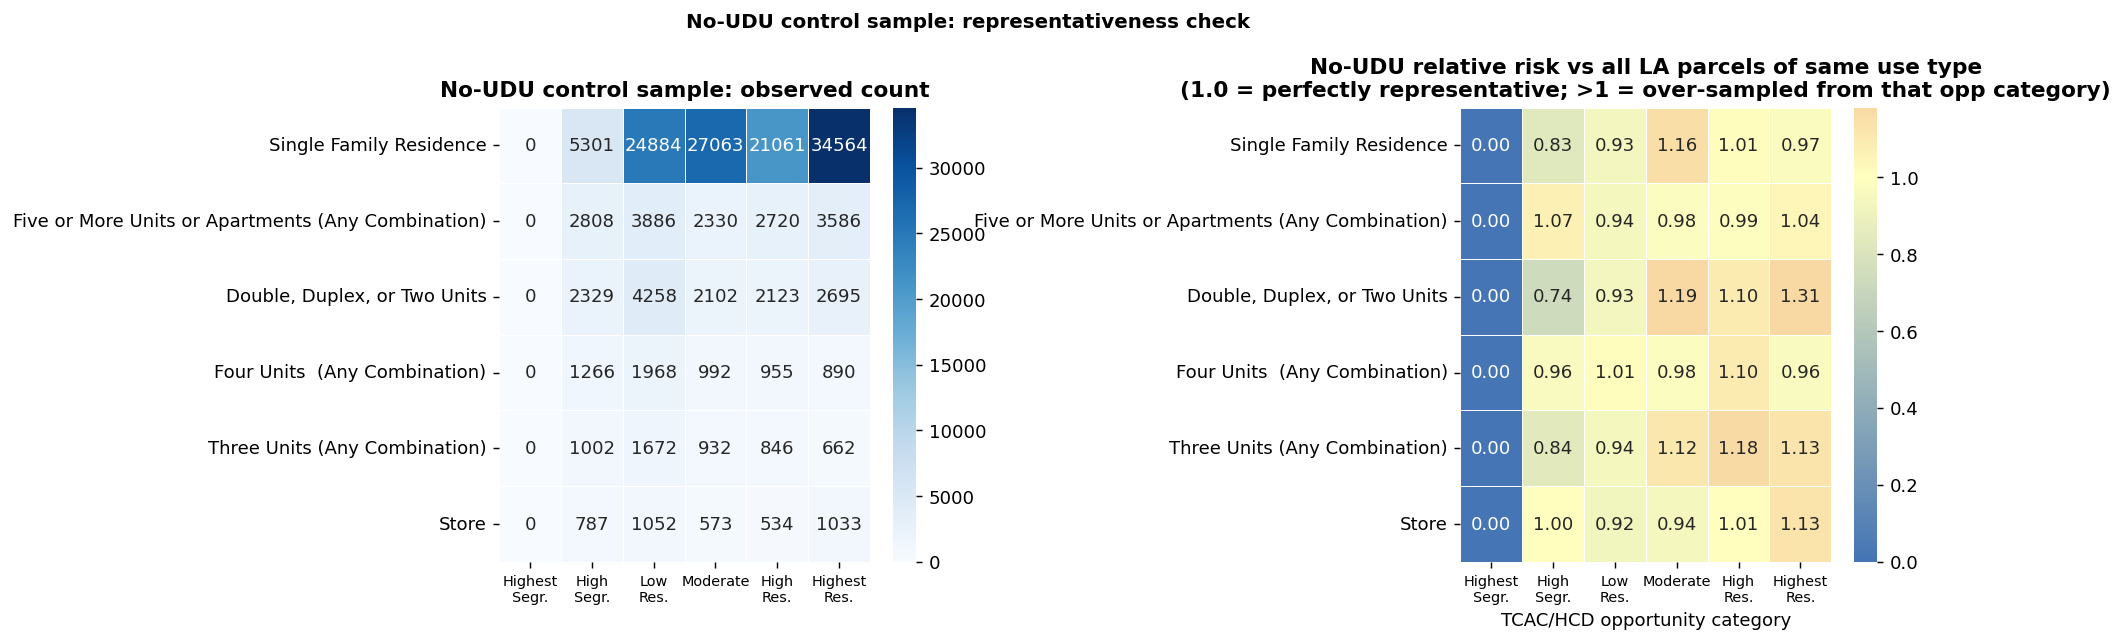

Cells most over/under-represented vs population (|RR-1| largest):


,SpecificUseType,opp_cat,n_no_udu,expected,rr
17,"Double, Duplex, or Two Units",Highest Resource,2695,2059.85,1.31
13,"Double, Duplex, or Two Units",High Segregation & Poverty,2329,3160.30,0.74
15,"Double, Duplex, or Two Units",Moderate Resource,2102,1773.37,1.19
28,Three Units (Any Combination),High Resource,846,719.95,1.18
1,Single Family Residence,High Segregation & Poverty,5301,6366.47,0.83
25,Three Units (Any Combination),High Segregation & Poverty,1002,1195.98,0.84
3,Single Family Residence,Moderate Resource,27063,23348.99,1.16
29,Three Units (Any Combination),Highest Resource,662,586.19,1.13
35,Store,Highest Resource,1033,915.03,1.13
27,Three Units (Any Combination),Moderate Resource,932,835.61,1.12


In [14]:
# ── No-UDU sample: count and relative risk vs assessor baseline ───────────────
# Same approach as UDU heatmap — how does the no-UDU control sample's
# opportunity-category distribution compare to all LA parcels of the same type?
# A balanced control should have RR ≈ 1.0 across all cells.

TOP_TYPES_NOUDU = no_udu['SpecificUseType'].value_counts().head(6).index.tolist()
SHORT_COLS = ['Highest\nSegr.','High\nSegr.','Low\nRes.','Moderate','High\nRes.','Highest\nRes.']

def make_ct_safe(df, types, opp_col='opp_cat'):
    return (
        df.dropna(subset=[opp_col])
        [df['SpecificUseType'].isin(types)]
        .groupby(['SpecificUseType', opp_col]).size()
        .unstack(opp_col, fill_value=0)
        .reindex(index=types, columns=OPPCAT_ORDER, fill_value=0)
    )

noudu_ct = make_ct_safe(no_udu, TOP_TYPES_NOUDU)
adp_ct_n = make_ct_safe(adp.dropna(subset=['SpecificUseType']), TOP_TYPES_NOUDU)

adp_row_share_n = adp_ct_n.div(adp_ct_n.sum(axis=1).replace(0, np.nan), axis=0)
expected_n      = adp_row_share_n.mul(noudu_ct.sum(axis=1), axis=0)
rr_n            = (noudu_ct / expected_n.replace(0, np.nan)).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(noudu_ct, ax=axes[0], cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, xticklabels=SHORT_COLS, linecolor='white')
axes[0].set_title('No-UDU control sample: observed count', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=8)

cmap_rr = mcolors.LinearSegmentedColormap.from_list('rr', ['#4575b4','#ffffbf','#d73027'])
vmax_n = min(3, float(np.nanpercentile(rr_n.replace(0, np.nan).values.flatten(), 95)))
sns.heatmap(rr_n, ax=axes[1], cmap=cmap_rr, center=1.0, vmin=0, vmax=vmax_n,
            annot=True, fmt='.2f', linewidths=0.5, xticklabels=SHORT_COLS, linecolor='white')
axes[1].set_title(
    'No-UDU relative risk vs all LA parcels of same use type\n'
    '(1.0 = perfectly representative; >1 = over-sampled from that opp category)',
    fontweight='bold')
axes[1].set_xlabel('TCAC/HCD opportunity category'); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('No-UDU control sample: representativeness check',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Summary: how far does the control deviate from 1.0?
rr_flat_n = (
    rr_n.stack().rename('rr').to_frame()
    .join(noudu_ct.stack().rename('n_no_udu'))
    .join(expected_n.stack().rename('expected'))
    .reset_index()
    .query('n_no_udu >= 20')
    .assign(deviation=lambda x: (x['rr'] - 1).abs())
    .sort_values('deviation', ascending=False)
    .head(10)
)
rr_flat_n.columns.name = None
print("Cells most over/under-represented vs population (|RR-1| largest):")
rr_flat_n[['SpecificUseType','opp_cat','n_no_udu','expected','rr']].round(2)


---
## Part 3 — Contamination Check

Even after the structural filters, some no-UDU parcels may look statistically identical to known UDU cases — either because their UDU pre-dates our study window or was never reported. The chart below shows how the two samples score on a per-use-type logistic regression trained to distinguish UDU from no-UDU. Parcels in the control sample with high predicted probability were removed.

FEAT_REPORT: 17 features — ['resid_floor_gap', 'imp_per_sqft', 'dominance_ratio', 'land_value_share', 'shape.n_buildings', 'struct_unit_gap', 'multi_bldg_flag', 'parcels.far', 'sp.bar', 'age_2017', 'renov_gap', 'bath_per_unit', 'bdrm_per_sqft', 'SQFTmain', 'opp_cat_rank', 'gross_sqft_geom', 'delta_gross_assr']


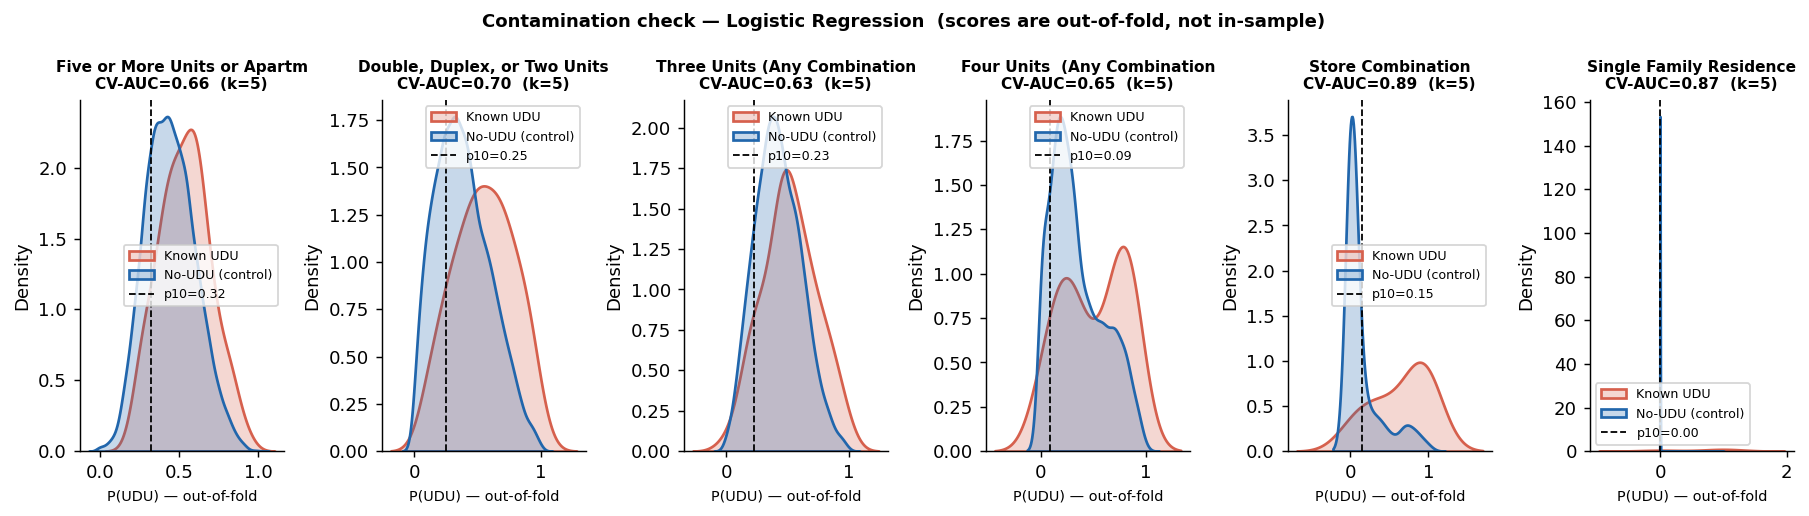

In [25]:
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Use only features available in combined (drop those with >30% NaN)
_candidate_feats = [
    'resid_floor_gap', 'imp_per_sqft', 'dominance_ratio', 'land_value_share',
    'shape.n_buildings', 'struct_unit_gap', 'multi_bldg_flag',
    'parcels.far', 'sp.bar', 'age_2017', 'renov_gap',
    'bath_per_unit', 'bdrm_per_sqft', 'SQFTmain', 'n_udu_tract', 'opp_cat_rank',
    # symdiff features — included only if well-populated
    'gross_sqft_geom', 'delta_gross_assr', 'lot_elongation',
]
FEAT_REPORT = [
    f for f in _candidate_feats
    if f in combined.columns
    and combined[f].notna().mean() > 0.7   # drop if >30% missing
]
print(f"FEAT_REPORT: {len(FEAT_REPORT)} features — {FEAT_REPORT}")

LOG_FEATS = ['gross_sqft_geom','delta_gross_assr','n_udu_tract','imp_per_sqft','resid_floor_gap']
TOP_TYPES = udu['SpecificUseType'].value_counts().head(6).index.tolist()

def make_model(scale_pos):
    if HAS_LGBM:
        return lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                   scale_pos_weight=scale_pos, random_state=42, verbose=-1)
    return Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(class_weight='balanced', max_iter=500))])

def prep_X(df):
    X = df.copy()
    for f in LOG_FEATS:
        if f in X.columns:
            X[f] = np.sign(X[f]) * np.log1p(np.abs(X[f]))
    return X

fitted_models = {}
fig, axes = plt.subplots(1, len(TOP_TYPES), figsize=(14, 4), sharey=False)

for ax, utype in zip(axes, TOP_TYPES):
    sub = combined[combined.SpecificUseType == utype][FEAT_REPORT + ['label']].dropna()
    n_pos = (sub.label == 'Known UDU').sum()
    n_neg = (sub.label != 'Known UDU').sum()
    if n_pos < 5 or n_neg < 2:
        ax.axis('off'); continue

    X_raw = prep_X(sub[FEAT_REPORT])
    y     = (sub['label'] == 'Known UDU').astype(int).values
    scale_pos = (y == 0).sum() / max(n_pos, 1)

    # ── Cross-validated AUC (honest out-of-sample estimate) ──────────────────
    n_splits = min(5, n_pos)          # never more folds than positive examples
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(y))

    try:
        for train_idx, val_idx in cv.split(X_raw, y):
            m = make_model(scale_pos)
            m.fit(X_raw.values[train_idx], y[train_idx])
            oof_probs[val_idx] = m.predict_proba(X_raw.values[val_idx])[:, 1]
        cv_auc = roc_auc_score(y, oof_probs)
    except Exception as e:
        ax.set_title(f'{utype[:28]}\nSkipped: {str(e)[:40]}', fontsize=7)
        ax.axis('off'); continue

    # ── Full-data fit for contamination scoring ───────────────────────────────
    full_model = make_model(scale_pos)
    full_model.fit(X_raw.values, y)
    fitted_models[utype] = {
        'model': full_model, 'feats': FEAT_REPORT,
        'cv_auc': round(cv_auc, 3), 'X': X_raw, 'y': y
    }

    # Plot OOF probability distributions
    oof_df = sub[['label']].copy()
    oof_df['prob'] = oof_probs
    thresh = oof_df[oof_df.label == 'Known UDU']['prob'].quantile(0.10)

    for label, grp in oof_df.groupby('label'):
        sns.kdeplot(grp['prob'], ax=ax, label=label,
                    color=PALETTE.get(label, 'grey'), fill=True, alpha=0.25, linewidth=1.5)
    ax.axvline(thresh, color='black', linestyle='--', linewidth=1,
               label=f'p10={thresh:.2f}')
    ax.set_title(f'{utype[:28]}\nCV-AUC={cv_auc:.2f}  (k={n_splits})',
                 fontsize=8.5, fontweight='bold')
    ax.set_xlabel('P(UDU) — out-of-fold', fontsize=8)
    ax.legend(fontsize=7)

model_name = 'LightGBM' if HAS_LGBM else 'Logistic Regression'
plt.suptitle(
    f'Contamination check — {model_name}  (scores are out-of-fold, not in-sample)',
    fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


In [26]:
# ── Feature dictionary ────────────────────────────────────────────────────────
feat_dict = pd.DataFrame([
    # Footprint / area signals
    ('gross_sqft_geom',   'Area',
     'Symdiff geometry footprint (sqft) × height-implied floor count',
     'area_2017_sqft × (lar_floorarea / lar_area_sqft). Uses the LiDAR-derived polygon area '
     'from the 2014→2017 building difference, scaled by the number of floors estimated '
     'from LARIAC building height ÷ 14 ft.'),

    ('delta_gross_assr',  'Area',
     'Gross sqft estimate minus assessor SQFTmain',
     'gross_sqft_geom − SQFTmain. Positive = physical structure appears larger than the '
     'assessor record; a key signal for unrecorded floor area.'),

    ('resid_floor_gap',   'Area',
     'ADP residential floor area minus assessor SQFTmain',
     'sp.resid.floorarea − SQFTmain. sp.resid.floorarea is the residential component of '
     'the spatial floor area from the ADP building features file.'),

    ('imp_per_sqft',      'Area',
     'Improvement value per recorded square foot',
     'ImprovementValue / SQFTmain. Low ratio suggests the assessed improvement value is '
     'small relative to the physical footprint — a sign of under-assessment.'),

    # Structural signals
    ('dominance_ratio',   'Structure',
     'Largest building footprint ÷ total footprint',
     'shape.area.max / shape.area.sum. Value near 1 = one dominant structure (typical SFR). '
     'Lower values indicate multiple comparably-sized buildings, consistent with an ADU '
     'alongside a main residence.'),

    ('land_value_share',  'Structure',
     'Land value as share of total assessed value',
     'LandValue / TotalValue. High share = property is under-improved relative to its '
     'land potential, suggesting informal additions may not be reflected in the assessment.'),

    ('shape.n_buildings', 'Structure',
     'Number of distinct LARIAC building footprints on parcel',
     'Count of separate building polygons assigned to the parcel in the LARIAC data.'),

    ('struct_unit_gap',   'Structure',
     'LARIAC structure count minus assessor-recorded unit count',
     'shape.n_buildings − Units. Positive = more physical structures than the assessor '
     'acknowledges as units — a direct inconsistency.'),

    ('multi_bldg_flag',   'Structure',
     'Assessor records more than one building data line',
     '1 if totBuildingDataLines > 1. The assessor stores a separate data line for each '
     'building on a parcel; more than one line confirms multiple structures.'),

    # Parcel characteristics
    ('parcels.far',       'Parcel',
     'Floor area ratio',
     'shape.floorarea.sum / parcels.area. Total estimated floor area of all LARIAC '
     'buildings divided by parcel area.'),

    ('sp.bar',            'Parcel',
     'Building coverage ratio (building area ÷ parcel area)',
     'shape.area.sum / parcels.area. Share of the parcel surface covered by building '
     'footprints.'),

    ('lot_elongation',    'Parcel',
     'Parcel bounding-box aspect ratio (proxy for deep/narrow lot)',
     'max(bbox_w, bbox_h) / min(bbox_w, bbox_h) from the UTM parcel geometry. '
     'High values = long narrow lots with space behind the main structure for a rear ADU.'),

    # Age / renovation
    ('age_2017',          'Age',
     'Building age in 2017',
     '2017 − YearBuilt. Older buildings have had more time to accumulate informal additions.'),

    ('renov_gap',         'Age',
     'Effective year built minus year built (renovation signal)',
     'clip(EffectiveYearBuilt − YearBuilt, 0). A positive gap means the assessor '
     'recognised improvements post-construction; a gap of 0 with a large footprint '
     'discrepancy may indicate unrecorded work.'),

    # Unit composition
    ('bath_per_unit',     'Composition',
     'Bathrooms per recorded unit',
     'Bathrooms / Units. A high ratio relative to peers of the same use type suggests '
     'additional bathrooms not tied to a recorded unit.'),

    ('bdrm_per_sqft',     'Composition',
     'Bedrooms per 100 sqft of assessed floor area',
     '(Bedrooms / SQFTmain) × 100. Dense bedroom count relative to recorded sqft may '
     'reflect informal room subdivision.'),

    ('SQFTmain',          'Size',
     'Assessor-recorded gross floor area (sqft)',
     'Directly from the LA County Assessor roll. Represents the main structures '
     'total floor area as assessed.'),

    # Neighbourhood
    ('n_udu_tract',       'Neighbourhood',
     'Count of known UDU filings in the same census tract',
     'Joined from assessor_udu_tracts.gpkg. Captures spatial clustering: tracts with '
     'existing UDU cases are more likely to contain additional undiscovered ones.'),

    ('opp_cat_rank',      'Neighbourhood',
     'TCAC/HCD 2021 opportunity category (ordered integer)',
     'From the California TCAC/HCD High Opportunity Map. Coded 0 (Highest Segregation '
     '& Poverty) → 5 (Highest Resource). Captures rent pressure and neighbourhood '
     'desirability as a driver of informal densification.'),

], columns=['Feature', 'Group', 'Short description', 'How computed'])

# Display as styled table
(feat_dict
 .set_index(['Group','Feature'])
 .style
 .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'font-size': '11px'})
 .set_table_styles([
     {'selector': 'th', 'props': [('text-align','left'),('font-size','11px')]},
     {'selector': 'td', 'props': [('vertical-align','top')]},
 ])
)


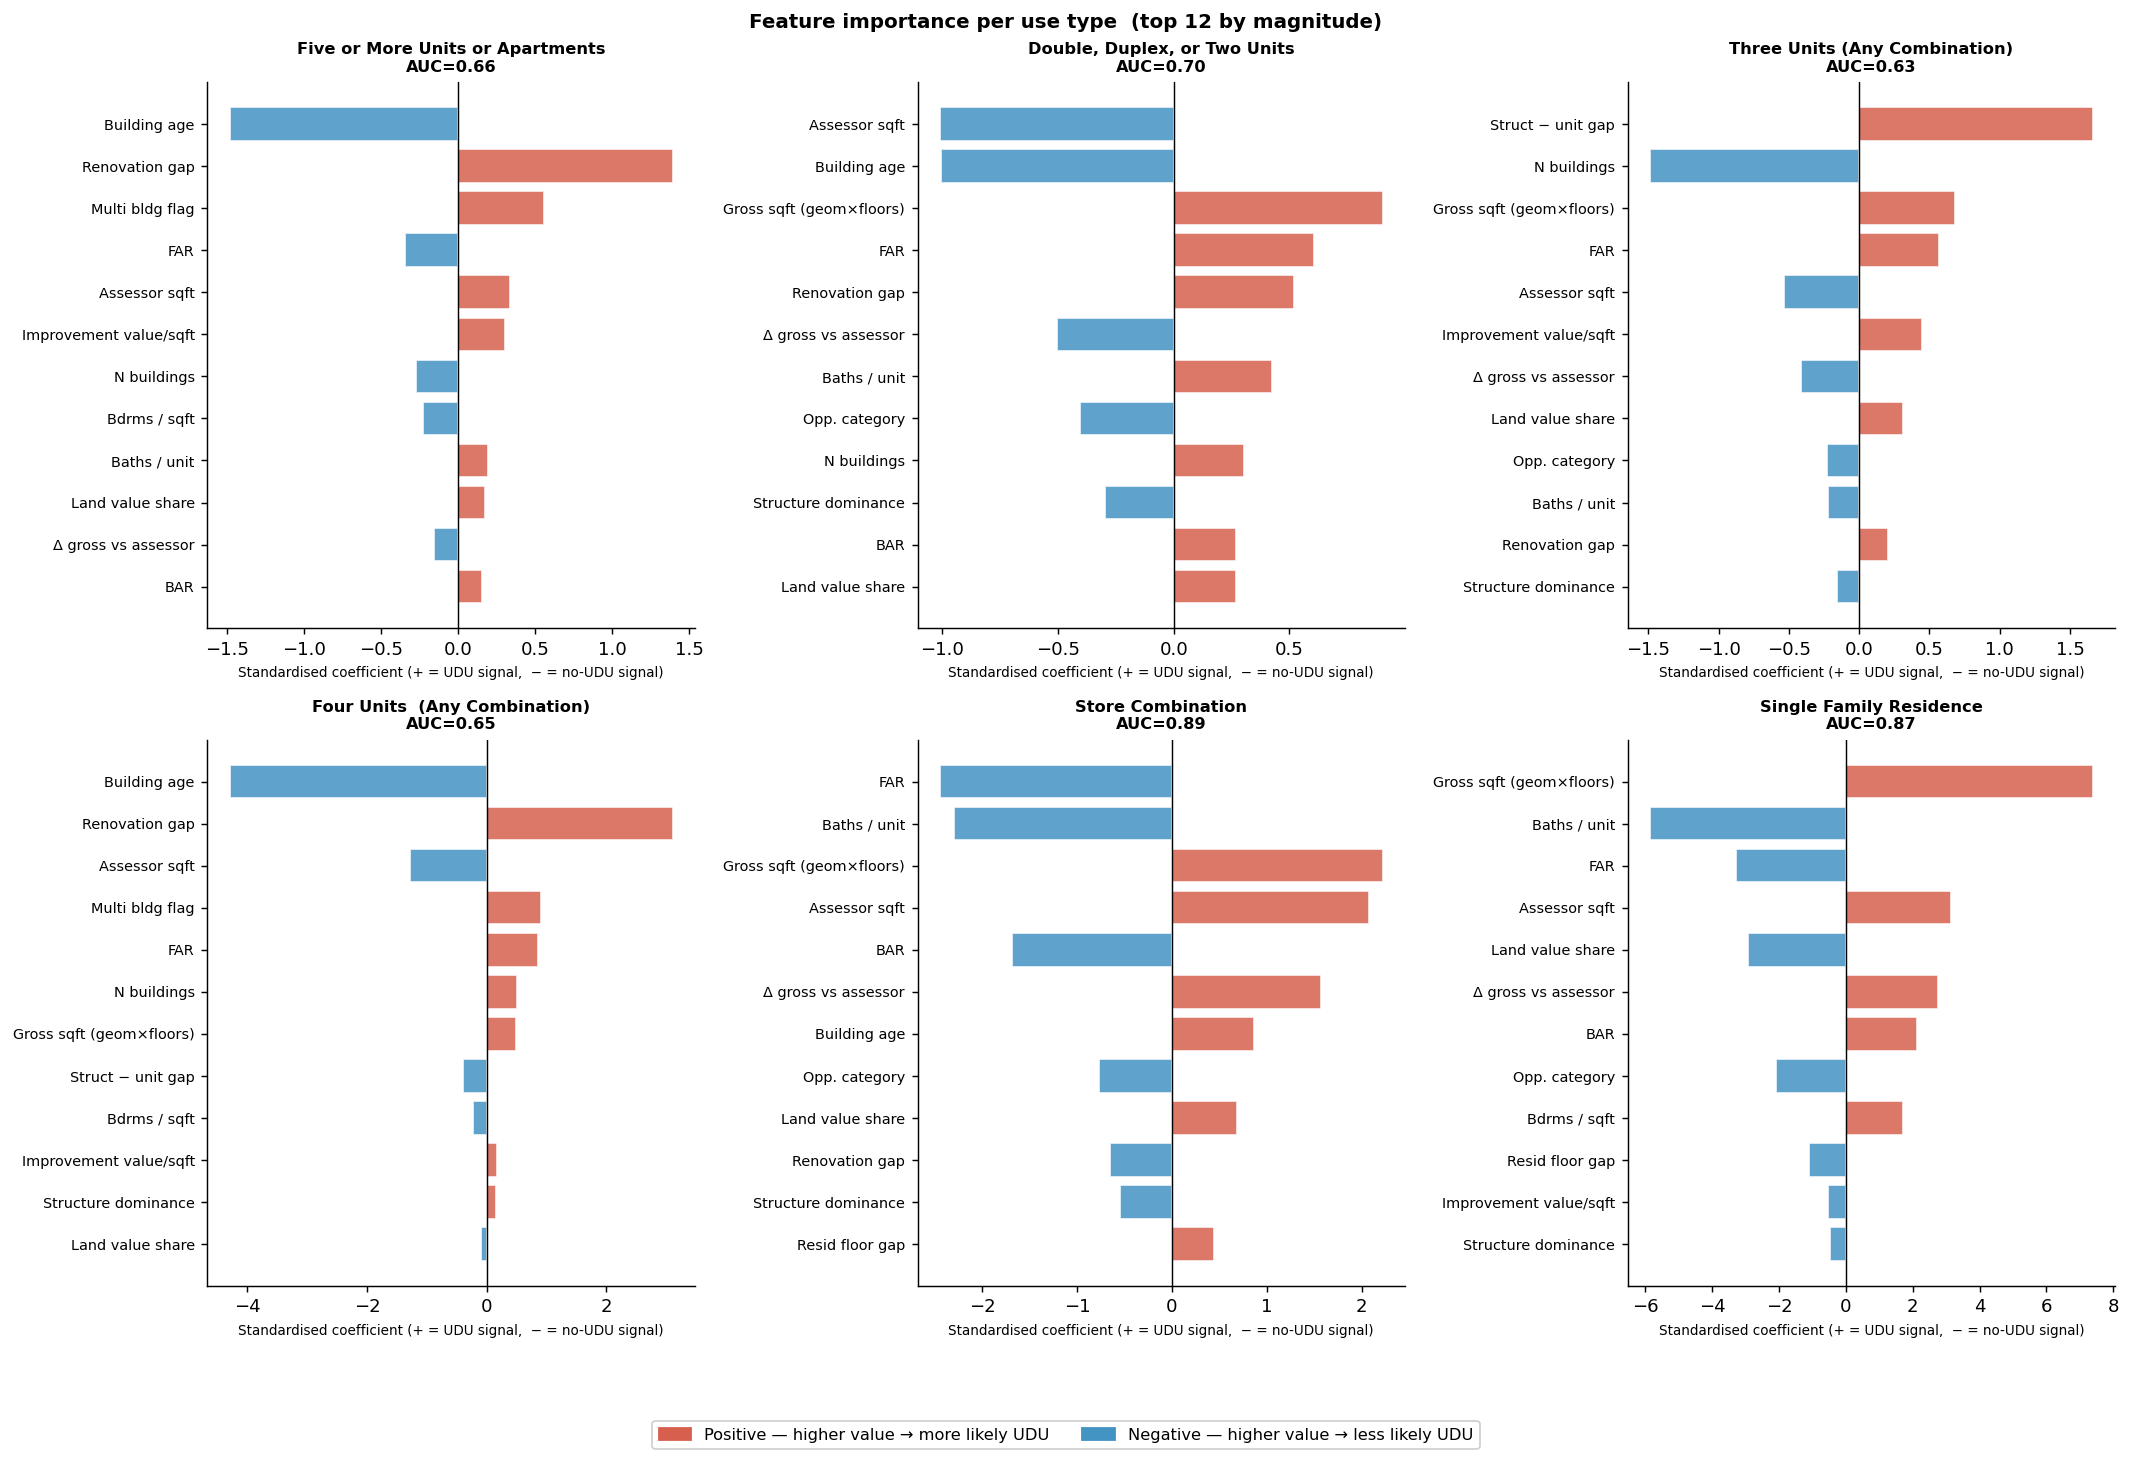

In [27]:
# ── Feature importance per use type — signed so direction is visible ──────────
# Logistic regression: signed standardised coefficient
#   positive (red)  → higher value = more likely UDU
#   negative (blue) → higher value = more likely no-UDU
# LightGBM: gain importance has no sign, so we use mean-difference direction
#   (mean feature value in UDU − mean in no-UDU, sign only)

FEAT_LABELS = {
    'gross_sqft_geom':   'Gross sqft (geom×floors)',
    'delta_gross_assr':  'Δ gross vs assessor',
    'resid_floor_gap':   'Resid floor gap',
    'imp_per_sqft':      'Improvement value/sqft',
    'dominance_ratio':   'Structure dominance',
    'land_value_share':  'Land value share',
    'shape.n_buildings': 'N buildings',
    'struct_unit_gap':   'Struct − unit gap',
    'multi_bldg_flag':   'Multi bldg flag',
    'parcels.far':       'FAR',
    'sp.bar':            'BAR',
    'lot_elongation':    'Lot elongation',
    'age_2017':          'Building age',
    'renov_gap':         'Renovation gap',
    'bath_per_unit':     'Baths / unit',
    'bdrm_per_sqft':     'Bdrms / sqft',
    'SQFTmain':          'Assessor sqft',
    'n_udu_tract':       'UDU in tract',
    'opp_cat_rank':      'Opp. category',
}

n_models = len(fitted_models)
if n_models == 0:
    print("Run the contamination check cell first.")
else:
    ncols = min(n_models, 3)
    nrows = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows))
    axes = np.array(axes).flatten()

    for ax, (utype, res) in zip(axes, fitted_models.items()):
        model, feats = res['model'], res['feats']
        X, y = res['X'], res['y']

        if HAS_LGBM and hasattr(model, 'feature_importances_'):
            # Unsigned gain — derive direction from mean difference UDU vs no-UDU
            raw  = model.feature_importances_.astype(float)
            mu_udu    = X.values[y == 1].mean(axis=0)
            mu_no_udu = X.values[y == 0].mean(axis=0)
            direction = np.sign(mu_udu - mu_no_udu)
            scores = raw * direction          # signed gain
            xlabel = 'Gain × direction (+ = UDU signal,  − = no-UDU signal)'
        else:
            # LR: coefficients are already signed
            scores = model['lr'].coef_[0]
            xlabel = 'Standardised coefficient (+ = UDU signal,  − = no-UDU signal)'

        importance = pd.Series(scores, index=feats)
        # Sort by absolute value, show top 12
        importance = importance.reindex(importance.abs().sort_values().tail(12).index)
        labels = [FEAT_LABELS.get(f, f) for f in importance.index]
        colors = ['#d6604d' if v > 0 else '#4393c3' for v in importance.values]

        ax.barh(range(len(importance)), importance.values,
                color=colors, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(importance)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel(xlabel, fontsize=7.5)
        ax.set_title(f'{utype[:32]}\nAUC={res["cv_auc"]:.2f}',
                     fontsize=9, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

    for ax in axes[n_models:]:
        ax.axis('off')

    # Shared legend
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color='#d6604d', label='Positive — higher value → more likely UDU'),
                        Patch(color='#4393c3', label='Negative — higher value → less likely UDU')],
               loc='lower center', ncol=2, fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.03))
    plt.suptitle('Feature importance per use type  (top 12 by magnitude)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()


In [ ]:
no_udu[['AIN','usetype','LotArea','lar_n_structures','ratio_floor_assr']].head(8)

---
## Key Takeaways

1. **Scale** — of ~625k LA City parcels with building footprints, roughly 27% (169k) pass all structural filters for high-confidence no-UDU status.

2. **UDU parcels are older** — the typical UDU parcel's building was constructed ~15–20 years earlier than the control, consistent with gradual informal densification of aging housing stock.

3. **UDU parcels are larger** — both in recorded floor area and number of on-site structures, reflecting the multi-unit character of many UDU properties.

4. **Floor area ratio** — UDU parcels show a higher FAR, indicating more building relative to lot size, which makes sense if an extra unit was added without permit.

5. **High-resource tracts** — UDU filings are over-represented in High and Highest Resource opportunity areas, suggesting rent pressure in desirable neighbourhoods is a key driver.

6. **Contamination is small but real** — the logistic regression finds a meaningful overlap between the tails of the two distributions, particularly for older multi-unit properties.

---
*Generated from notebooks/tasks/09_find_no_udu.ipynb. Run nb_09 first to save AIN checkpoints, then run this notebook.*
